## Notebook de comparaison du modèle optimisé et du modèle de base.


In [14]:
import torch.nn as nn

#Création de la classe universelle pour les modèles de réseaux de neurones

class UniversalCNN(nn.Module):
    def __init__(self, use_batch_norm=False, dropout_rate=0.0): #parametres permettant de choisir si on prend la classe optimisé ou non
        super(UniversalCNN, self).__init__()
        layers = []
        in_channels = 3
        out_channels = 16

        for _ in range(5):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_batch_norm:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = out_channels
            out_channels *= 2

        self.features = nn.Sequential(*layers)

        classifier_layer = [
            nn.Flatten(),
            nn.Linear((out_channels//2)*8*8, 256),]
        if dropout_rate > 0:
            classifier_layer.append(nn.Dropout(dropout_rate))
        classifier_layer.append(nn.ReLU())
        classifier_layer.append(nn.Linear(256, 2))
        self.classifier = nn.Sequential(*classifier_layer)
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
#Création du data loader
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch

transform = transforms.Compose([transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

test_dataset = datasets.ImageFolder(root='../data/clean/test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [16]:
model_basic = UniversalCNN(use_batch_norm=False, dropout_rate=0.0).to(device)
model_optimized = UniversalCNN(use_batch_norm=True, dropout_rate=0.5).to(device)

#chargement des poids des modèles
model_basic.load_state_dict(torch.load('../models/best_model_epoch_7.pth'))
model_optimized.load_state_dict(torch.load('../models/optimized_model.pth'))

model_basic.eval()
model_optimized.eval()


C:\Users\abdal\AppData\Local\Temp\ipykernel_10200\2245953253.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_basic.load_state_dict(torch.load('../models/best_model

UniversalCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [17]:
import time
#Ajout de la bibliothèque time pour mesurer le temps d'évaluation

def evaluate_model(model, dataloader):
    all_preds, all_labels, errors = [], [], []
    correct, total, accuracy = 0, 0, 0
    start_time = time.time()
    with torch.no_grad():
        
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
                # Enregistrer les erreurs de classification
            for i in range(len(labels)):
                if (predicted[i] != labels[i]) and (len(errors) < 10):  # Limiter à 10 erreurs pour l'affichage
                    errors.append({'image': images[i].cpu(), 'label': labels[i].item(), 'pred': predicted[i].item()})
    end_time = time.time()
    images_time = (end_time - start_time) / total  # Temps moyen par image
    accuracy = correct / total
    return accuracy, images_time, errors, all_preds, all_labels


In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def confusion_matrix_and_report(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    report = classification_report(labels, preds, target_names=['cat', 'dog'])
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['cat', 'dog'], yticklabels=['cat', 'dog'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    print("Classification Report:\n", report)


,Model,Accuracy,Time per Image (s)
0,Baseline,0.898082,0.007849
1,Optimized,0.957634,0.007227


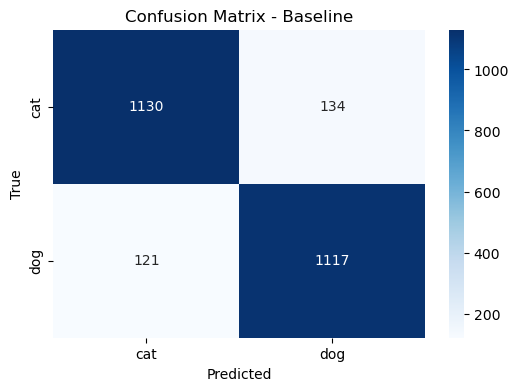

Classification Report:
               precision    recall  f1-score   support

         cat       0.90      0.89      0.90      1264
         dog       0.89      0.90      0.90      1238

    accuracy                           0.90      2502
   macro avg       0.90      0.90      0.90      2502
weighted avg       0.90      0.90      0.90      2502



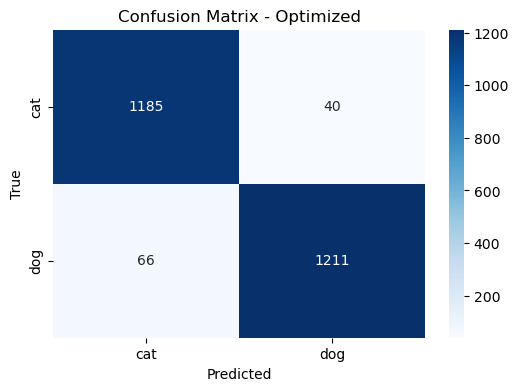

Classification Report:
               precision    recall  f1-score   support

         cat       0.95      0.97      0.96      1225
         dog       0.97      0.95      0.96      1277

    accuracy                           0.96      2502
   macro avg       0.96      0.96      0.96      2502
weighted avg       0.96      0.96      0.96      2502



In [19]:
result_baseline = evaluate_model(model_basic, test_loader)
result_optimized = evaluate_model(model_optimized, test_loader)

data = {
    'Model': ['Baseline', 'Optimized'],
    'Accuracy': [result_baseline[0], result_optimized[0]],
    'Time per Image (s)': [result_baseline[1], result_optimized[1]]
}

df = pd.DataFrame(data)
display(df)

confusion_matrix_and_report(result_baseline[3], result_baseline[4], "Baseline")
confusion_matrix_and_report(result_optimized[3], result_optimized[4], "Optimized")


On remarque que le modèle de base à une réussite de 90% et le modèle optimisé de 96%, de plus notre batch normalization nous a permis d'aller plus vite sur le modèle optimisé.


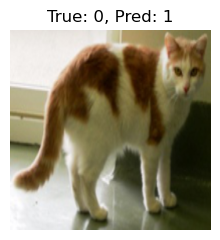

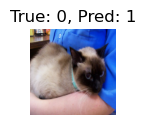

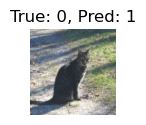

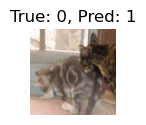

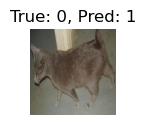

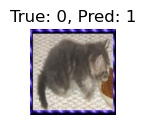

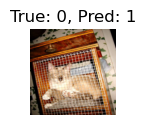

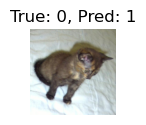

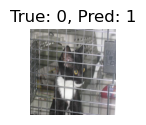

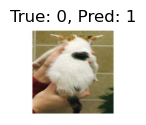

In [21]:
errors = result_optimized[2]  # Afficher les erreurs du modèle optimisé
plt.figure(figsize=(15, 15))
for i, error in enumerate(errors):
    plt.subplot(2, 5, i + 1)
    img = error['image'].permute(1, 2, 0) * 0.5 + 0.5  # Denormalize
    plt.imshow(img)
    plt.title(f"True: {error['label']}, Pred: {error['pred']}")
    plt.axis('off')
    plt.show()

## Résultat

On remarque que le modèle optimisé est bien plus performant que le modèle de base, mais qu'il a un peu plus de mal à détecter les chats que les chiens.
